<Figure size 640x480 with 0 Axes>

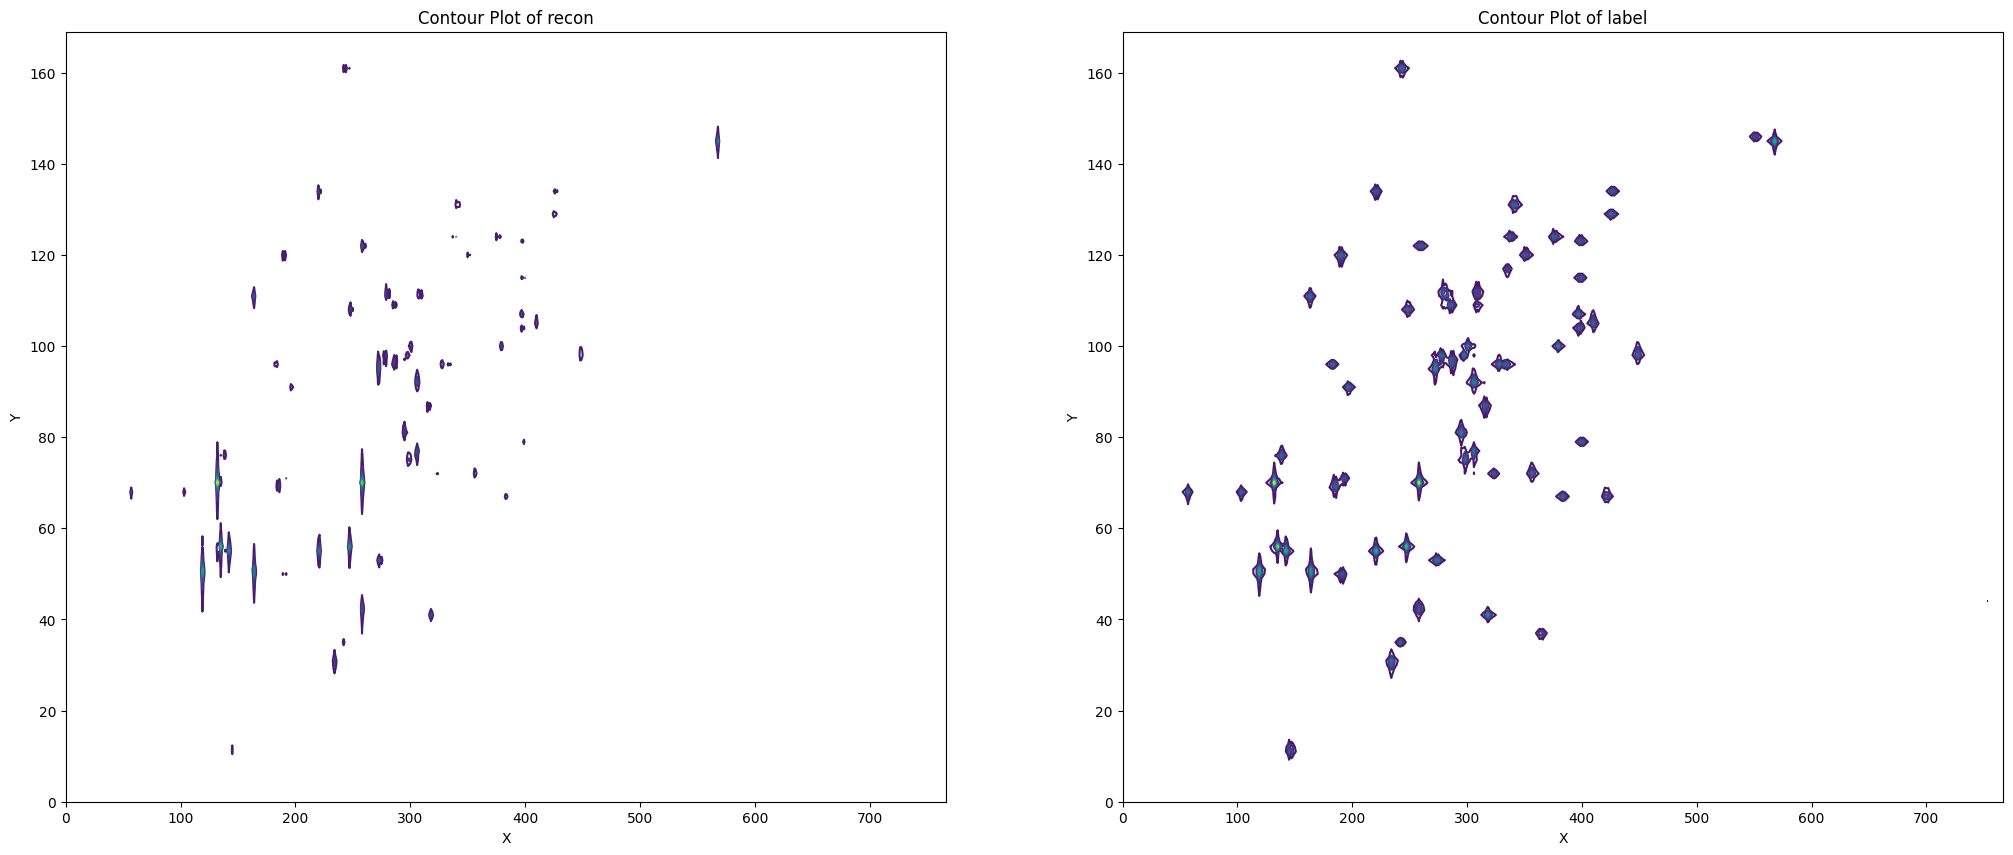

3.445964813232422


In [5]:
# WWN 2D data
import os
import torch
import sys
sys.path.append('./WNN')
from WNN.datadc import *

from WNN.WNN1 import *
import matplotlib
import matplotlib.pyplot as plt
import time


os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4"


def getLevels(min, fac, num):
    return np.array([min*(fac**i) for i in range(num)])


def plot_contour(ax, ft_outer, col='viridis', lvl=None, invert=False):
    #ft_outer = ft_outer.numpy()[0, :, :]

    if lvl is None:
        lvl = getLevels(np.max(ft_outer.numpy()) * 0.035, 1.3, 22)
        # lvl = np.arange(0, 20, 1)

    plt.contour(ft_outer, levels=lvl, cmap=col)
    #ax.contour(ft_outer, levels=lvl, cmap=col)

def net_test_2d(net=None, device=None):
    device = device
    test_data = MyDataset(test_list)
    test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                              batch_size=1,
                                              shuffle=False)
    net.eval()


    for step, (src_data, trg_data,time_data_real,time_data_imag) in enumerate(test_loader):
        src_data = src_data.type(torch.FloatTensor)
        trg_data = trg_data.type(torch.FloatTensor)
        src_data = src_data.to(device)
        trg_data = trg_data.to(device)
        src_data = src_data.unsqueeze(1)
        trg_data = trg_data.unsqueeze(1)

        time_data_real = time_data_real.type(torch.FloatTensor)
        time_data_real = time_data_real.to(device)
        time_data_real = time_data_real.unsqueeze(1)

        time_data_imag = time_data_imag.type(torch.FloatTensor)
        time_data_imag = time_data_imag.to(device)
        time_data_imag = time_data_imag.unsqueeze(1)
        [x_output] = net(src_data, time_data_real, time_data_imag)
        output = x_output.cpu()
        total_output[:, step, :] = output.detach()
        out = total_output



    out = out.cpu()
    out = out.detach().reshape(N2, N1).numpy()
    out1d = np.transpose(out)
    total_out = (out/500) * max_under
    max_out = np.max(np.max(total_out))
    out = np.transpose(total_out/max_out)
    recon = torch.tensor(out)

    fig = plt.figure(figsize=(25, 10))
    contour_levels = 15

    ax = fig.add_subplot(121)
    contour_input = ax.contour(recon[:256-pad_zeros, :], levels=contour_levels, cmap='viridis')
    ax.set_title('Contour Plot of recon')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax = fig.add_subplot(122)
    contour_input = ax.contour(torch.tensor(abs(np.transpose(ideal1[:, :256-pad_zeros]))), levels=contour_levels, cmap='viridis')
    ax.set_title('Contour Plot of label')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()


    recon_spec = out[:256-pad_zeros, :]
    scio.savemat('recon_spec.mat', {'recon_spec': recon_spec})


if __name__ == "__main__":
    device = torch.device("cuda:0")
    N1 = 170
    array = 10
    total_output = torch.zeros(1, N2, N1)
    ideal = np.transpose(ideal)
    ideal = torch.tensor(ideal)

    plt.figure(1)
    ax2 = (1, 1)

    under = abs(torch.tensor(np.transpose(under)))


    net = torch.load(r'WNN/WNN_0.15_170_maskrandom.pth')
    net = net.to(device)
    time_start = time.time()
    net_test_2d(net, device)
    time_end = time.time()
    time_cost = time_end - time_start
    print(time_cost)


227


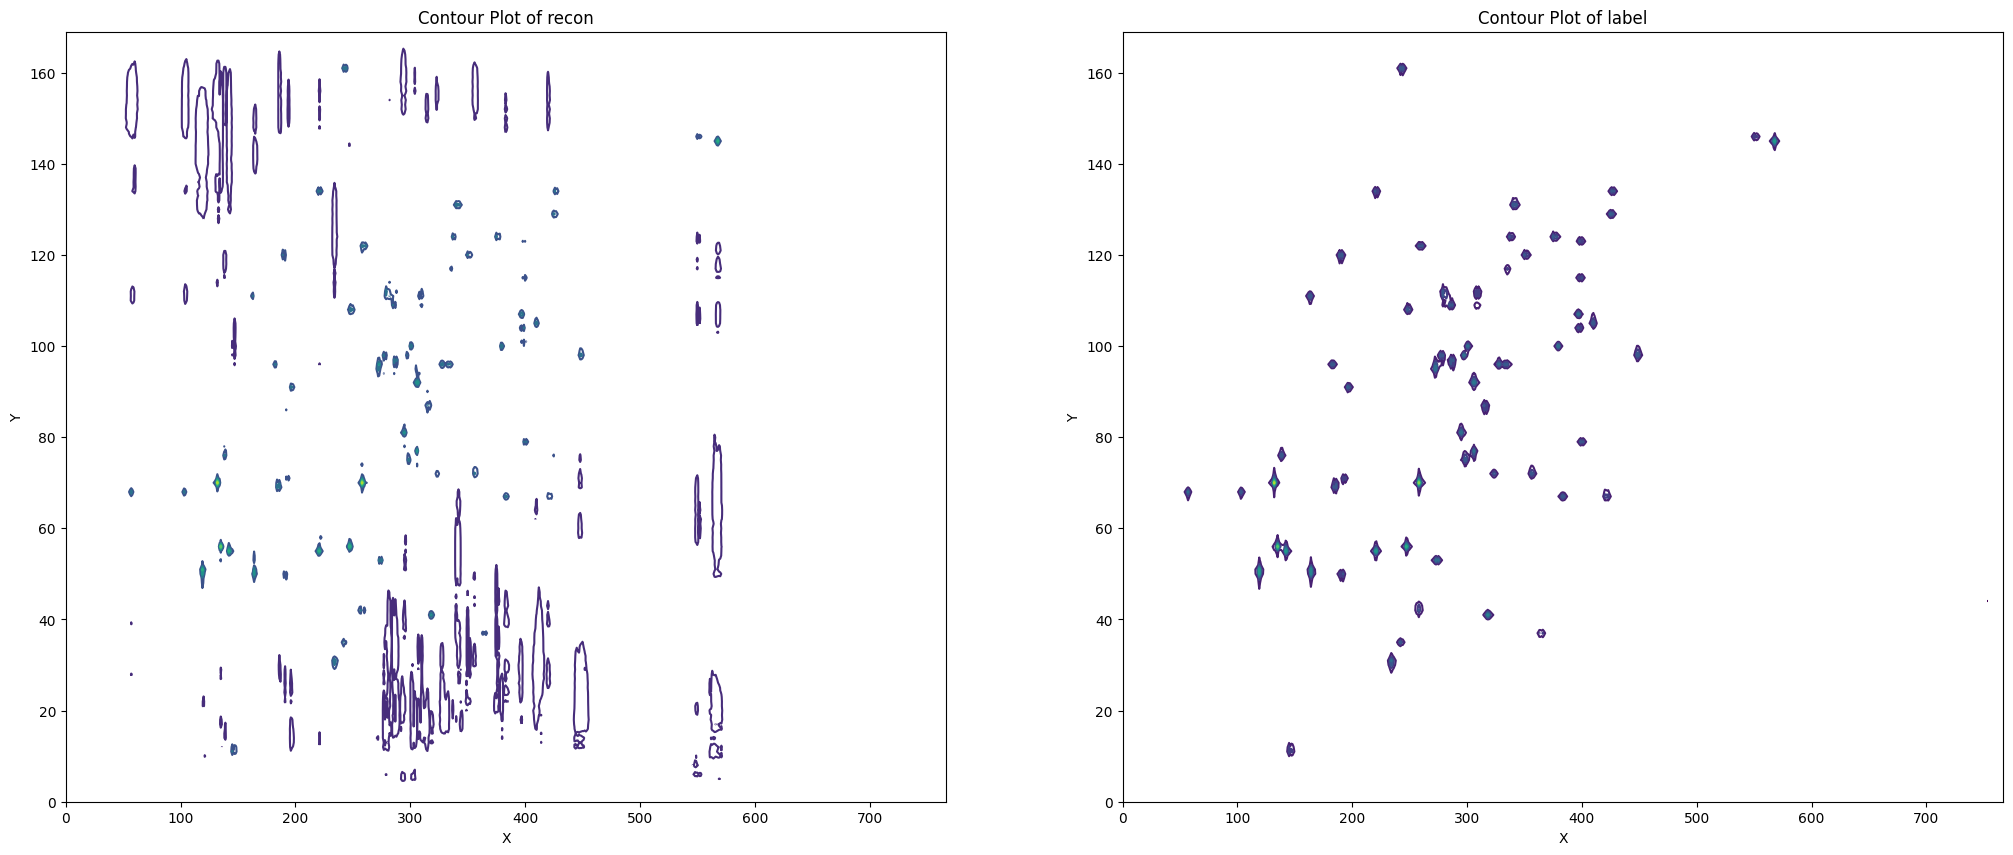

In [2]:
#EDHRN 2D data
import os
os.environ["CUDA_VISIBLE_DEVICES"] = '0,1,2,3,4'
import torch
import numpy as np
import sys
sys.path.insert(0, './EDHRN') 

from EDHRN.data import *
from EDHRN.model import *
from model import *
import matplotlib
import matplotlib.pyplot as plt


def getLevels(min, fac, num):
    return np.array([min*(fac**i) for i in range(num)])


def plot_contour(ax, ft_outer, col='viridis', lvl=None, invert=False):

    if lvl is None:
        lvl = getLevels(np.max(ft_outer.numpy()) * 0.035, 1.2, 22)

    plt.contour(ft_outer, levels=8, cmap=col)



def net_test_2d(device=None):
    device=device
    test_data = MyDataset(test_list)
    test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                              batch_size=1,
                                              shuffle=False)
    net.eval()


    for step, (src_data, trg_data) in enumerate(test_loader):
        src_data = src_data.type(torch.FloatTensor)
        trg_data = trg_data.type(torch.FloatTensor)
        src_data = src_data.to(device)
        trg_data = trg_data.to(device)
        output = net(src_data)
        output = output.cpu()
        total_output[:, step, :] = output.detach()
        out = total_output
    out = out.cpu()
    out = out.detach().reshape(N2, N1).numpy()
    out1d = np.transpose(out)
    out = np.transpose(out*max_under)
    recon = torch.tensor(out)

    fig = plt.figure(figsize=(25, 10))
    contour_levels = 10

    ax = fig.add_subplot(121)
    contour_input = ax.contour(recon[:256-pad_zeros, :], levels=8, cmap='viridis')
    ax.set_title('Contour Plot of recon')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # plt.colorbar(contour_input, ax=ax, label='Amplitude')
    ax = fig.add_subplot(122)
    contour_input = ax.contour(torch.tensor(abs(np.transpose(ideal1[:, :256-pad_zeros]))), levels=contour_levels, cmap='viridis')
    ax.set_title('Contour Plot of label')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    # plt.colorbar(contour_input, ax=ax, label='Amplitude')
    plt.show()

    recon_spec = out[:256-pad_zeros, :]
    scio.savemat('recon_spec.mat', {'recon_spec': recon_spec})
    plt.show()



if __name__ == "__main__":
    device = torch.device("cuda:0")
    N1 = 170

    array = 10
    total_output = torch.zeros(1, N2, N1)

    ideal = np.transpose(ideal)
    ideal = torch.tensor(ideal)


    ideal1d=ideal[:, array].clone().detach()

    under = abs(torch.tensor(np.transpose(under)))


    under1d = under[:, array].clone().detach()

    net = torch.load("EDHRN/edhr_rate0.15_170_maskfixed.pth", map_location=device)

    net_test_2d(device)

349


<Figure size 640x480 with 0 Axes>

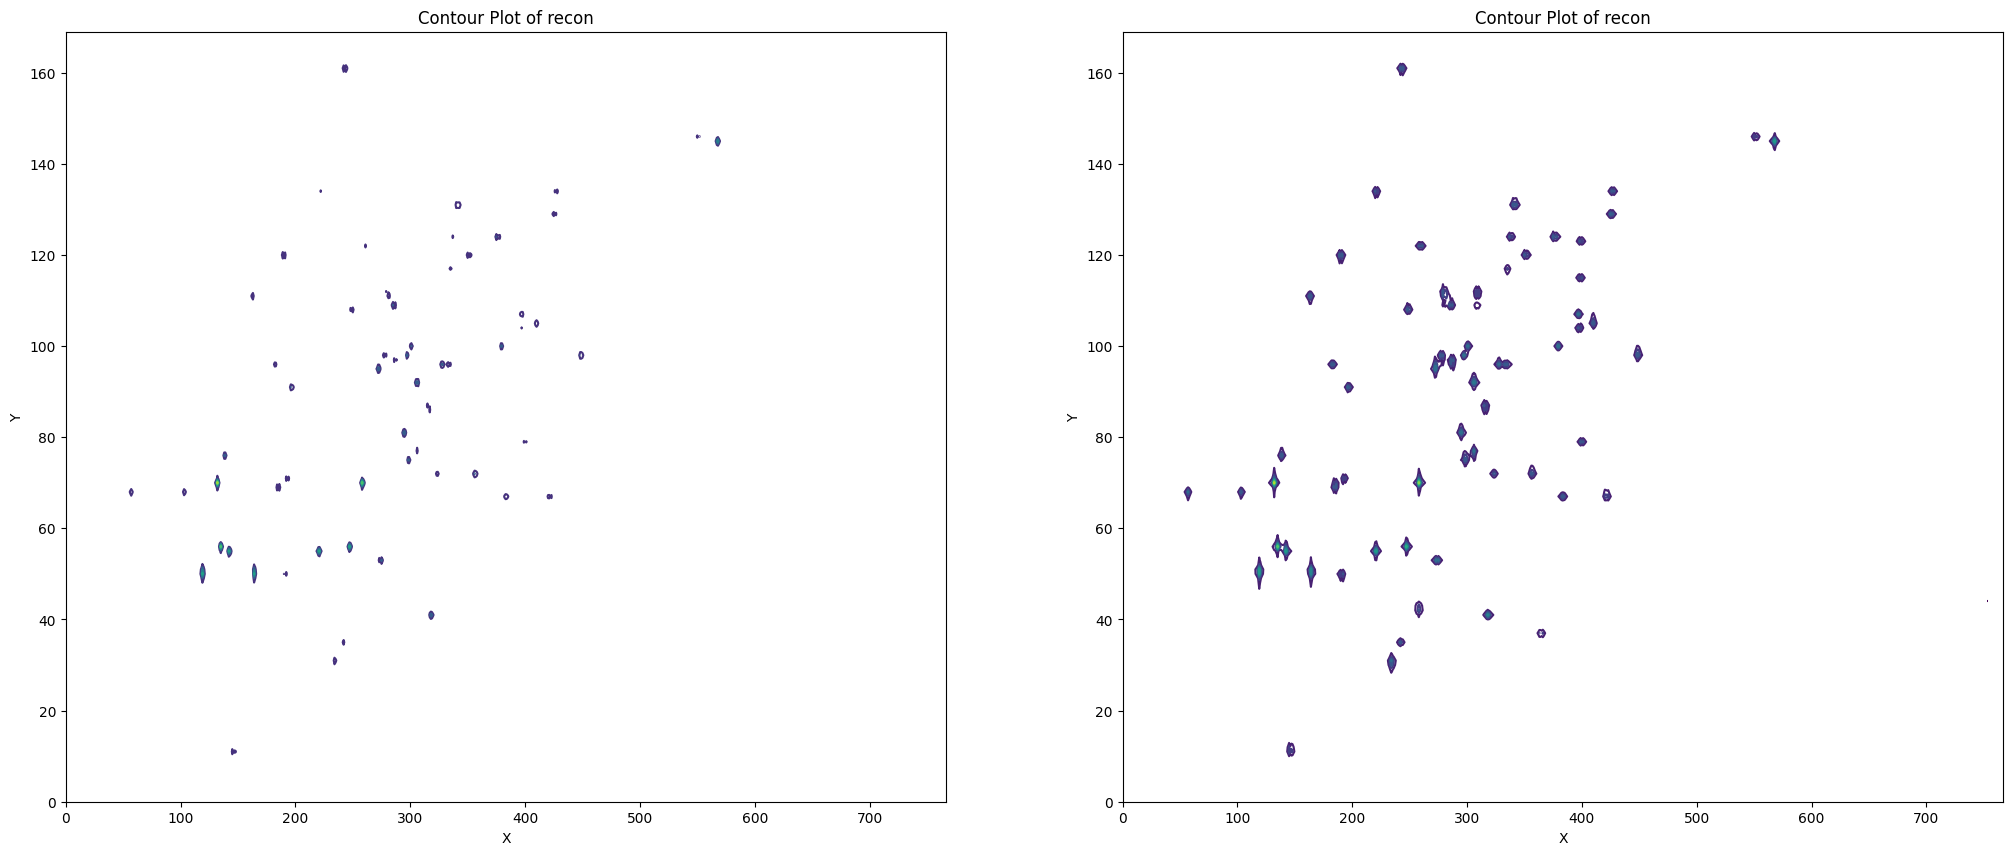

42.063106298446655


In [3]:
#Densenet 2D data
import os
import torch
import sys
import importlib

for m in ['model', 'data', 'Densenet.model', 'Densenet.data', 'EDHRN.model', 'EDHRN.data']:
    if m in sys.modules:
        del sys.modules[m]

DENSENET_DIR = os.path.abspath('./Densenet')
sys.path.insert(0, DENSENET_DIR)
from Densenet.data import *
from Densenet.model import *
from model import  *
import matplotlib
import matplotlib.pyplot as plt
import time

os.environ["CUDA_VISIBLE_DEVICES"] = "0,1,2,3,4"

def getLevels(min, fac, num):
    return np.array([min*(fac**i) for i in range(num)])

def plot_contour(ax, ft_outer, col='viridis', lvl=None, invert=False):
    if lvl is None:
        lvl = getLevels(np.max(ft_outer.numpy()) * 0.035, 1.3, 22)
    plt.contour(ft_outer, levels=lvl, cmap=col)

def net_test_2d(net=None, device=None):
    device = device
    test_data = MyDataset(test_list)
    test_loader = torch.utils.data.DataLoader(dataset=test_data,
                                              batch_size=1,
                                              shuffle=False)
    net.eval()


    for step, (src_data, trg_data,time_data_real,time_data_imag) in enumerate(test_loader):
        src_data = src_data.type(torch.FloatTensor)
        trg_data = trg_data.type(torch.FloatTensor)
        src_data = src_data.to(device)
        trg_data = trg_data.to(device)
        src_data = src_data.unsqueeze(1)
        trg_data = trg_data.unsqueeze(1)

        time_data_real = time_data_real.type(torch.FloatTensor)
        time_data_real = time_data_real.to(device)
        time_data_real = time_data_real.unsqueeze(1)

        time_data_imag = time_data_imag.type(torch.FloatTensor)
        time_data_imag = time_data_imag.to(device)
        time_data_imag = time_data_imag.unsqueeze(1)
        [x_output] = net(src_data, time_data_real, time_data_imag)
        output = x_output.cpu()
        total_output[:, step, :] = output.detach()
        out = total_output

    out = out.cpu()
    out = out.detach().reshape(N2, N1).numpy()
    out1d = np.transpose(out)
    total_out = (out/500) * max_under
    max_out = np.max(np.max(total_out))
    out = np.transpose(total_out/max_out)

    recon = torch.tensor(out)

    fig = plt.figure(figsize=(25, 10))
    contour_levels = 10

    ax = fig.add_subplot(121)
    contour_input = ax.contour(recon[:256-pad_zeros, :], levels=8, cmap='viridis')
    ax.set_title('Contour Plot of recon')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    ax = fig.add_subplot(122)
    contour_input = ax.contour(torch.tensor(abs(np.transpose(ideal1[:, :256-pad_zeros]))), levels=contour_levels, cmap='viridis')
    ax.set_title('Contour Plot of recon')
    ax.set_xlabel('X')
    ax.set_ylabel('Y')
    plt.show()


    recon_spec = out[:256-pad_zeros, :]
    scio.savemat('recon_spec.mat', {'recon_spec': recon_spec})


if __name__ == "__main__":
    device = torch.device("cuda:0")
    N1 = 170
    array = 10
    total_output = torch.zeros(1, N2, N1)
    ideal = np.transpose(ideal)
    ideal = torch.tensor(ideal)

    plt.figure(1)
    ax2 = (1, 1)

    under = abs(torch.tensor(np.transpose(under)))


    net = torch.load(r'Densenet/dense_rate0.15_170_maskrandom_solve.pth', map_location=device)
    net = net.to(device)
    time_start = time.time()
    net_test_2d(net, device)
    time_end = time.time()
    time_cost = time_end - time_start
    print(time_cost)